# Phase 2b : Direct Force-Coefficient Surrogates

**Project:** A data-driven surrogate for airfoil shape optimization, built on the AirfRANS benchmark

**Author:** Muhammad Uns Haider Shah

## Motivation
Phase 2 showed that the field surrogates predict and rank **lift** reliably but not **drag**. Viscous drag, 68 % of the total, is overestimated about 28-fold, because wall shear depends on velocity gradients across a first cell only 2 µm thick. Pressure drag, a small residual of large opposing pressure forces, still has a 60 % median error even though surface pressure is accurate. Neither error can be removed by post-processing alone, and both optimization problems in Phase 3 depend on drag.

## Approach
Lift and drag are smooth functions of a few quantities: airfoil shape, angle of attack and Reynolds number. They are therefore regressed **directly**, bypassing the flow field:

$$(\mathbf{g},\ \alpha,\ Re)\ \mapsto\ (C_L,\ \log C_D)$$

where $\mathbf{g}$ is the 13-number shape descriptor from Phase 1b. Drag is modelled in log space because it is strictly positive and spans a wide range. Two model classes are compared:

* **Neural-network ensemble.** Small, smooth (SiLU) networks; differentiable with respect to the inputs, as needed for gradient-based optimization in Phase 3. The spread across members serves as an uncertainty estimate.
* **Gaussian process.** The standard surrogate of Bayesian optimization, with calibrated predictive uncertainty (Matérn-5/2 kernel with one length scale per input).

Both use **the same 160 training and 40 validation cases** as the field models, and are evaluated on the same 200 test cases with the Phase 2 metrics.

**Runtime:** Google Colab (GPU optional). Requires the Drive dataset cache and the Phase 1, 1b and 2 outputs.

## 1. Environment

In [ ]:
# pyvista is pinned: 0.49+ requires a newer IPython than the Colab runtime provides
!pip install -q airfrans "pyvista==0.48.0" "vtk<9.7"
import airfrans as af
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch, torch.nn as nn
import os, glob, json, time, gc

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'NO GPU: change the runtime type')
from scipy.spatial import cKDTree
from scipy.stats import spearmanr
from airfrans.naca_generator import camber_line, naca_generator
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
import joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 5.6 MB/s eta 0:00:00
device: cuda | Tesla T4


## 2. Configuration

In [ ]:
CFG = dict(
    seed         = 0,
    widths       = [32, 64],                # ensemble hyperparameter grid
    weight_decay = [1e-2, 1e-1, 1.0],        # AdamW decay is scaled by the learning rate
    grid_seeds   = 3,                       # members per grid point during selection
    n_members    = 10,                      # members in the final ensemble
    epochs       = 3000,                    # full-batch optimisation steps
    lr           = 3e-3,
    gp_restarts  = 5,
)
EVAL = dict(pair_daoa=1.0, pair_dre=0.5e6, pair_min_rel=0.05)
SURF_COL = 11
torch.manual_seed(CFG['seed']); np.random.seed(CFG['seed'])

## 3. Dataset

In [ ]:
import shutil, zipfile
from google.colab import drive

USE_DRIVE = True
DRIVE_DIR = '/content/drive/MyDrive/airfrans'
DRIVE_ZIP = f'{DRIVE_DIR}/Dataset.zip'
ROOT_DL   = '/content/airfrans_data'
LOCAL_ZIP = f'{ROOT_DL}/Dataset.zip'

def have_data():
    return bool(glob.glob(f'{ROOT_DL}/**/manifest.json', recursive=True))

def gb(path):
    return os.path.getsize(path) / 1e9

if USE_DRIVE:
    drive.mount('/content/drive')
    os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(ROOT_DL, exist_ok=True)

if have_data():
    print('Dataset already extracted on this machine.')
elif USE_DRIVE and os.path.exists(DRIVE_ZIP):
    print(f'Copying {gb(DRIVE_ZIP):.1f} GB zip from Drive (unzipping from local disk is much faster)...')
    shutil.copy(DRIVE_ZIP, LOCAL_ZIP)
    print('Unzipping...')
    with zipfile.ZipFile(LOCAL_ZIP) as z:
        z.extractall(ROOT_DL)
else:
    print('No cached copy found. Downloading from the AirfRANS server (slow, one time only)...')
    af.dataset.download(root=ROOT_DL, file_name='Dataset', unzip=True, OpenFOAM=False)

# Cache to Drive if it isn't there yet. This only runs after a successful unzip,
# so a broken or partial download never gets saved.
if USE_DRIVE and os.path.exists(LOCAL_ZIP) and have_data():
    if not os.path.exists(DRIVE_ZIP) or gb(DRIVE_ZIP) != gb(LOCAL_ZIP):
        print(f'Saving {gb(LOCAL_ZIP):.1f} GB zip to Drive (10-20 min, one time only)...')
        shutil.copy(LOCAL_ZIP, DRIVE_ZIP)
    print(f'Drive copy OK: {gb(DRIVE_ZIP):.2f} GB  (local {gb(LOCAL_ZIP):.2f} GB)')

print('Data ready:', have_data())

Mounted at /content/drive
Copying 10.0 GB zip from Drive (unzipping from local disk is much faster)...
Unzipping...
Drive copy OK: 10.03 GB  (local 10.03 GB)
Data ready: True


In [ ]:
# The loader needs the folder that contains manifest.json. Find it rather than guessing.
ROOT = os.path.dirname(glob.glob(f'{ROOT_DL}/**/manifest.json', recursive=True)[0])
print('Dataset root:', ROOT)

# Free disk space: the zip is no longer needed locally once extracted
zip_path = f'{ROOT_DL}/Dataset.zip'
if os.path.exists(zip_path):
    os.remove(zip_path)

with open(f'{ROOT}/manifest.json') as f:
    manifest = json.load(f)
for k, v in manifest.items():
    print(f'{k:15s} {len(v):5d} simulations')

Dataset root: /content/airfrans_data/Dataset
full_train        800 simulations
scarce_train      200 simulations
reynolds_train    504 simulations
aoa_train         804 simulations
full_test         200 simulations
reynolds_test     496 simulations
aoa_test          196 simulations


## 4. Utilities

In [ ]:
import numpy as np

def order_surface(pos, normals):
    """Return indices that walk the airfoil surface as a closed loop:
    upper surface leading edge -> trailing edge, then lower surface trailing edge -> leading edge.
    Works whichever way the normals point (inward or outward)."""
    g1 = np.where(normals[:, 1] < 0)[0]
    g2 = np.where(normals[:, 1] >= 0)[0]
    # The upper-surface group is the one sitting higher on average
    upper, lower = (g1, g2) if pos[g1, 1].mean() > pos[g2, 1].mean() else (g2, g1)
    upper = upper[np.argsort(pos[upper, 0])]     # LE -> TE
    lower = lower[np.argsort(-pos[lower, 0])]    # TE -> LE
    return np.concatenate([upper, lower]), len(upper)

def pressure_force_coefficients(pos, normals, p, u_inf, aoa_rad):
    """Integrate surface pressure (kinematic, p/rho) to pressure-only lift and drag coefficients.
    pos, normals, p: surface nodes only. Returns (cd_p, cl_p)."""
    idx, _ = order_surface(pos, normals)
    P, N, pp = pos[idx], normals[idx], p[idx].ravel()
    # Length "owned" by each node = half of each neighbouring segment on the closed loop
    seg = np.linalg.norm(np.roll(P, -1, axis=0) - P, axis=1)
    L = 0.5 * (seg + np.roll(seg, 1))
    # Make normals point OUT of the body: on average they should point away from the centroid
    sign = np.sign(np.mean(np.sum((P - P.mean(axis=0)) * N, axis=1)))
    n_out = sign * N / np.linalg.norm(N, axis=1, keepdims=True)
    F = -(pp[:, None] * n_out * L[:, None]).sum(axis=0)       # force / rho
    drag_dir = np.array([np.cos(aoa_rad), np.sin(aoa_rad)])
    lift_dir = np.array([-np.sin(aoa_rad), np.cos(aoa_rad)])
    q = 0.5 * u_inf**2
    return F @ drag_dir / q, F @ lift_dir / q

def parse_name(name):
    """AirfRANS names look like airFoil2D_SST_<Uinf>_<AoA deg>_<NACA params...>"""
    parts = name.split('_')
    u_inf, aoa = float(parts[2]), float(parts[3])
    naca = [float(v) for v in parts[4:]]
    return u_inf, aoa, naca


In [ ]:
def shape_descriptor(naca):
    naca = np.asarray(naca, dtype=float)
    if len(naca) == 3:
        params_c, t = naca[:2], naca[2] / 100
    elif len(naca) == 4:
        params_c, t = naca[:3], naca[3] / 100
    else:
        raise ValueError(f'unexpected NACA parameters {naca}')
    y_c, _ = camber_line(params_c, STATIONS.copy())
    return np.concatenate([[t], y_c]).astype(np.float32)

family = lambda n: '4-digit' if len(parse_name(n)[2]) == 3 else '5-digit'

In [ ]:
P1_DIR  = os.path.join(DRIVE_DIR if USE_DRIVE else '/content', 'phase1')
P1B_DIR = os.path.join(DRIVE_DIR if USE_DRIVE else '/content', 'phase1b')
P2_DIR  = os.path.join(DRIVE_DIR if USE_DRIVE else '/content', 'phase2')
OUT_DIR = os.path.join(DRIVE_DIR if USE_DRIVE else '/content', 'phase2b')
os.makedirs(OUT_DIR, exist_ok=True)

ck = torch.load(f'{P1B_DIR}/mlp_shape_best.pt', map_location='cpu', weights_only=False)
STATIONS = np.array(ck['cfg']['stations'])
G_NAMES = ['t'] + [f'yc@{x:g}' for x in STATIONS]
with open(f'{P1_DIR}/phase1_summary.json') as f:
    VAL_NAMES = set(json.load(f)['val_names'])
print('descriptor:', G_NAMES)

descriptor: ['t', 'yc@0.025', 'yc@0.05', 'yc@0.1', 'yc@0.2', 'yc@0.3', 'yc@0.4', 'yc@0.5', 'yc@0.6', 'yc@0.7', 'yc@0.8', 'yc@0.9', 'yc@0.95']


## 5. Force coefficients of the training cases
Reference $C_L$ and $C_D$ for the 200 *scarce* training cases, computed with `Simulation.force_coefficient()` exactly as for the test set in Phase 2. Results are cached on Drive; test-set references are taken from the Phase 2 results.

In [ ]:
CSV = f'{OUT_DIR}/train_forces.csv'
done = pd.read_csv(CSV) if os.path.exists(CSV) else pd.DataFrame()
done_names = set(done['name']) if len(done) else set()
todo = [n for n in manifest['scarce_train'] if n not in done_names]
print(f'{len(done_names)} cached, {len(todo)} to compute')

rows, t0 = [], time.time()
for k, name in enumerate(todo):
    sim = af.Simulation(root=ROOT, name=name)
    u, aoa, _ = parse_name(name)
    (cd, cdp, cdv), (cl, clp, clv) = sim.force_coefficient(reference=True)
    rows.append(dict(name=name, u_inf=u, aoa=aoa, re=u / float(sim.NU), family=family(name),
                     true_cd=cd, true_cdp=cdp, true_cdv=cdv, true_cl=cl, true_clp=clp, true_clv=clv))
    if len(rows) == 20 or k == len(todo) - 1:
        done = pd.concat([done, pd.DataFrame(rows)], ignore_index=True)
        done.to_csv(CSV, index=False); rows = []
        print(f'  {k + 1}/{len(todo)} | {time.time() - t0:.0f} s')

train_all = pd.read_csv(CSV)
test = pd.read_csv(f'{P2_DIR}/test_forces.csv')
train = train_all[~train_all['name'].isin(VAL_NAMES)].reset_index(drop=True)
val   = train_all[train_all['name'].isin(VAL_NAMES)].reset_index(drop=True)
assert len(val) == len(VAL_NAMES), 'validation cases missing'
print(f'train {len(train)} | val {len(val)} | test {len(test)}')
print(f"true CD range {train_all['true_cd'].min():.4f} – {train_all['true_cd'].max():.4f}  |  "
      f"CL range {train_all['true_cl'].min():.3f} – {train_all['true_cl'].max():.3f}")

0 cached, 200 to compute
  20/200 | 37 s
  40/200 | 55 s
  60/200 | 75 s
  80/200 | 95 s
  100/200 | 114 s
  120/200 | 141 s
  140/200 | 164 s
  160/200 | 182 s
  180/200 | 201 s
  200/200 | 220 s
train 160 | val 40 | test 200
true CD range 0.0075 – 0.0459  |  CL range -0.487 – 1.775


## 6. Inputs and targets
Inputs: shape descriptor, angle of attack (degrees) and Reynolds number (millions). Targets: $C_L$ and $\log C_D$. Both are standardised with training-set statistics.

In [ ]:
IN_NAMES = G_NAMES + ['aoa', 're_M']

def features(df):
    G = np.stack([shape_descriptor(parse_name(n)[2]) for n in df['name']])
    return np.hstack([G, df[['aoa']].values, df[['re']].values / 1e6]).astype(np.float64)

def targets(df):
    return np.c_[df['true_cl'].values, np.log(df['true_cd'].values)]

X_tr, X_va, X_te = features(train), features(val), features(test)
Y_tr, Y_va = targets(train), targets(val)
xm, xs = X_tr.mean(0), X_tr.std(0) + 1e-12
ym, ys = Y_tr.mean(0), Y_tr.std(0)
nx = lambda X: (X - xm) / xs
ny = lambda Y: (Y - ym) / ys
STATS2B = dict(xm=xm.tolist(), xs=xs.tolist(), ym=ym.tolist(), ys=ys.tolist(), in_names=IN_NAMES)
print(pd.DataFrame({'min': X_tr.min(0), 'max': X_tr.max(0)}, index=IN_NAMES).round(4).to_string())

             min      max
t         0.0501   0.1994
yc@0.025  0.0000   0.0149
yc@0.05   0.0000   0.0274
yc@0.1    0.0000   0.0452
yc@0.2    0.0000   0.0556
yc@0.3    0.0000   0.0634
yc@0.4    0.0000   0.0694
yc@0.5    0.0000   0.0687
yc@0.6    0.0000   0.0666
yc@0.7    0.0000   0.0631
yc@0.8    0.0000   0.0515
yc@0.9    0.0000   0.0305
yc@0.95   0.0000   0.0164
aoa      -4.7900  14.8370
re_M      2.0304   5.9957


## 7. Neural-network ensemble
Each member is a two-hidden-layer network with smooth activations, trained full-batch with AdamW and a cosine learning-rate schedule. Width and weight decay are chosen on the validation cases (averaged over three seeds per setting); the final ensemble then uses ten members with the selected setting.

In [ ]:
class ForceMLP(nn.Module):
    def __init__(self, n_in, width):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, width), nn.SiLU(),
                                 nn.Linear(width, width), nn.SiLU(),
                                 nn.Linear(width, 2))
    def forward(self, x):
        return self.net(x)

T = lambda a: torch.as_tensor(a, dtype=torch.float32, device=DEVICE)
Xtr_t, Ytr_t, Xva_t = T(nx(X_tr)), T(ny(Y_tr)), T(nx(X_va))

def train_member(seed, width, wd):
    torch.manual_seed(seed)
    net = ForceMLP(len(IN_NAMES), width).to(DEVICE)
    opt = torch.optim.AdamW(net.parameters(), lr=CFG['lr'], weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, CFG['epochs'])
    for _ in range(CFG['epochs']):
        loss = ((net(Xtr_t) - Ytr_t) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    net.eval()
    return net

@torch.no_grad()
def ens_predict(nets, X):
    # Returns mean and std of [CL, log CD] in physical units
    P = torch.stack([n(T(nx(X))) for n in nets]).cpu().numpy() * ys + ym
    return P.mean(0), P.std(0)

t0 = time.time()
grid = []
for w in CFG['widths']:
    for wd in CFG['weight_decay']:
        nets = [train_member(100 + s, w, wd) for s in range(CFG['grid_seeds'])]
        mu, _ = ens_predict(nets, X_va)
        err = ((ny(mu) - ny(Y_va)) ** 2).mean(0)
        grid.append(dict(width=w, weight_decay=wd, val_mse_cl=err[0], val_mse_logcd=err[1], val_mse=err.mean()))
grid = pd.DataFrame(grid).sort_values('val_mse')
print(grid.to_string(index=False, float_format=lambda v: f'{v:.4g}'))
best_w, best_wd = int(grid.iloc[0]['width']), float(grid.iloc[0]['weight_decay'])
print(f'\nselected: width {best_w}, weight decay {best_wd:g}  ({time.time() - t0:.0f} s)')

ensemble = [train_member(s, best_w, best_wd) for s in range(CFG['n_members'])]
torch.save(dict(states=[n.state_dict() for n in ensemble], width=best_w, weight_decay=best_wd,
                stats=STATS2B, cfg=CFG, stations=STATIONS.tolist()), f'{OUT_DIR}/force_ensemble.pt')
print(f'ensemble of {len(ensemble)} trained and saved ({time.time() - t0:.0f} s total)')

 width  weight_decay  val_mse_cl  val_mse_logcd  val_mse
    64          0.01    0.000403         0.6996     0.35
    64           0.1   0.0003445         0.7021   0.3512
    32          0.01   0.0003749         0.7066   0.3535
    32           0.1   0.0003675         0.7097   0.3551
    64             1   0.0001306         0.7181   0.3591
    32             1   0.0001958         0.7321   0.3661

selected: width 64, weight decay 0.01  (90 s)
ensemble of 10 trained and saved (135 s total)


## 8. Gaussian process
One GP per target (on standardised data), with kernel $\sigma^2\,\text{Matérn}_{5/2}(\ell_1,\dots,\ell_{15}) + \sigma_n^2$. Hyperparameters are fitted by maximising the marginal likelihood. An input whose length scale grows to the upper bound has effectively no influence. This is expected here, because the 13 descriptor entries are functions of only three or four NACA parameters.

In [ ]:
def make_gp():
    kernel = (ConstantKernel(1.0, (1e-2, 1e2))
              * Matern(length_scale=np.ones(len(IN_NAMES)), length_scale_bounds=(1e-2, 1e3), nu=2.5)
              + WhiteKernel(1e-3, (1e-8, 1e0)))
    return GaussianProcessRegressor(kernel, normalize_y=False, n_restarts_optimizer=CFG['gp_restarts'],
                                    random_state=CFG['seed'])

t0 = time.time()
import warnings
from sklearn.exceptions import ConvergenceWarning
with warnings.catch_warnings():
    # Length scales reaching the upper bound simply mean the GP ignores that input
    warnings.simplefilter('ignore', ConvergenceWarning)
    gps = [make_gp().fit(nx(X_tr), ny(Y_tr)[:, k]) for k in range(2)]
print(f'GPs fitted in {time.time() - t0:.0f} s')

def gp_predict(X):
    out = [g.predict(nx(X), return_std=True) for g in gps]
    mu = np.c_[out[0][0], out[1][0]] * ys + ym
    sd = np.c_[out[0][1], out[1][1]] * ys
    return mu, sd

mu_va, _ = gp_predict(X_va)
print('validation MSE (standardised): CL {:.4g}, log CD {:.4g}'.format(*((ny(mu_va) - ny(Y_va)) ** 2).mean(0)))

ls = pd.Series(gps[1].kernel_.k1.k2.length_scale, index=IN_NAMES)
print('\nlearned length scales for log CD (short = influential; 1000 = input effectively ignored):')
print(ls.sort_values().round(3).to_string())
joblib.dump(dict(gps=gps, stats=STATS2B, stations=STATIONS.tolist()), f'{OUT_DIR}/force_gp.joblib')

GPs fitted in 19 s
validation MSE (standardised): CL 0.0002947, log CD 0.677

learned length scales for log CD (short = influential; 1000 = input effectively ignored):
aoa            8.100
t              8.285
yc@0.2        28.570
yc@0.8        34.374
re_M          56.150
yc@0.4       111.749
yc@0.025     247.724
yc@0.1      1000.000
yc@0.5      1000.000
yc@0.3      1000.000
yc@0.05     1000.000
yc@0.6      1000.000
yc@0.9      1000.000
yc@0.7      1000.000
yc@0.95     1000.000


['/content/drive/MyDrive/airfrans/phase2b/force_gp.joblib']

## 9. Test-set accuracy and ranking
The same metrics as Phase 2, with the shape-aware field model (no-slip variant) as reference.

In [ ]:
mu_nn, sd_nn = ens_predict(ensemble, X_te)
mu_gp, sd_gp = gp_predict(X_te)
for tag, mu, sd in (('nn', mu_nn, sd_nn), ('gp', mu_gp, sd_gp)):
    test[f'{tag}_cl'], test[f'{tag}_cd'] = mu[:, 0], np.exp(mu[:, 1])
    test[f'{tag}_cl_sd'], test[f'{tag}_logcd_sd'] = sd[:, 0], sd[:, 1]
MODELS = [('sa_ns', 'field: shape-aware MLP'), ('nn', 'direct: NN ensemble'), ('gp', 'direct: Gaussian process')]
for m, _ in MODELS + [('true', '')]:
    test[f'{m}_ld'] = test[f'{m}_cl'] / test[f'{m}_cd']

rel = lambda m, c: (test[f'{m}_{c}'] - test[f'true_{c}']).abs() / test[f'true_{c}'].abs()
rows = []
for m, lab in MODELS:
    r = dict(model=lab)
    for c, C in (('cd', 'CD'), ('cl', 'CL'), ('ld', 'L/D')):
        e = rel(m, c)
        r[f'{C} rel. err (mean)'] = e.mean(); r[f'{C} rel. err (median)'] = e.median()
    for c, C in (('cd', 'ρ_D'), ('cl', 'ρ_L'), ('ld', 'ρ_L/D')):
        r[C] = spearmanr(test[f'{m}_{c}'], test[f'true_{c}'])[0]
    rows.append(r)
acc = pd.DataFrame(rows).set_index('model')
print(acc.T.to_string(float_format=lambda v: f'{v:.3f}'))

model                  field: shape-aware MLP  direct: NN ensemble  direct: Gaussian process
CD rel. err (mean)                     18.153                0.016                     0.009
CD rel. err (median)                   17.152                0.008                     0.003
CL rel. err (mean)                      0.096                0.021                     0.008
CL rel. err (median)                    0.026                0.006                     0.003
L/D rel. err (mean)                     0.935                0.033                     0.016
L/D rel. err (median)                   0.944                0.012                     0.007
ρ_D                                     0.075                0.998                     0.999
ρ_L                                     0.998                1.000                     1.000
ρ_L/D                                   0.883                0.997                     0.999


**Pairwise ordering at comparable conditions** (same definition and windows as Phase 2).

In [ ]:
i, j = np.triu_indices(len(test), 1)
near = (np.abs(test['aoa'].values[i] - test['aoa'].values[j]) <= EVAL['pair_daoa']) & \
       (np.abs(test['re'].values[i] - test['re'].values[j]) <= EVAL['pair_dre'])

def pair_acc(m, c, mask):
    t, p = test[f'true_{c}'].values, test[f'{m}_{c}'].values
    ok = np.sign(t[i] - t[j]) == np.sign(p[i] - p[j])
    dist = np.abs(t[i] - t[j]) > EVAL['pair_min_rel'] * np.maximum(np.abs(t[i]), np.abs(t[j]))
    frac = lambda sel: ok[sel].mean() if sel.any() else np.nan
    return frac(mask), frac(mask & dist)

rows = []
for m, lab in MODELS:
    r = dict(model=lab)
    for c, C in (('cl', 'CL'), ('cd', 'CD'), ('ld', 'L/D')):
        r[f'{C}: all pairs'] = pair_acc(m, c, np.ones_like(near))[0]
        r[f'{C}: comparable'], r[f'{C}: comparable & distinguishable'] = pair_acc(m, c, near)
    rows.append(r)
pairs = pd.DataFrame(rows).set_index('model')
print(f'{near.sum()} comparable pairs; fraction ordered correctly (0.5 = chance)\n')
print(pairs.T.to_string(float_format=lambda v: f'{v:.3f}'))

479 comparable pairs; fraction ordered correctly (0.5 = chance)

model                              field: shape-aware MLP  direct: NN ensemble  direct: Gaussian process
CL: all pairs                                       0.984                0.997                     0.998
CL: comparable                                      0.971                0.990                     1.000
CL: comparable & distinguishable                    0.988                0.998                     1.000
CD: all pairs                                       0.526                0.986                     0.993
CD: comparable                                      0.628                0.967                     0.983
CD: comparable & distinguishable                    0.658                0.995                     1.000
L/D: all pairs                                      0.866                0.982                     0.990
L/D: comparable                                     0.843                0.971                 

## 10. Uncertainty calibration
For a trustworthy optimizer, the predicted uncertainty should be honest. The table gives the fraction of test cases whose true value lies within ±1σ and ±2σ of the prediction; a well-calibrated Gaussian predictor gives about 68 % and 95 %.

In [ ]:
rows = []
for m, lab in MODELS[1:]:
    for tgt, err, sd in (('CL', test[f'{m}_cl'] - test['true_cl'], test[f'{m}_cl_sd']),
                         ('log CD', np.log(test[f'{m}_cd']) - np.log(test['true_cd']), test[f'{m}_logcd_sd'])):
        z = np.abs(err) / sd
        rows.append(dict(model=lab, target=tgt, within_1sd=(z <= 1).mean(), within_2sd=(z <= 2).mean(),
                         median_sd=np.median(sd)))
calib = pd.DataFrame(rows)
print(calib.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
print('\nThe ensemble spread reflects only disagreement between members, so it typically underestimates the error.')

                   model target  within_1sd  within_2sd  median_sd
     direct: NN ensemble     CL       0.535       0.785      0.003
     direct: NN ensemble log CD       0.285       0.545      0.004
direct: Gaussian process     CL       0.685       0.905      0.003
direct: Gaussian process log CD       0.745       0.905      0.006

The ensemble spread reflects only disagreement between members, so it typically underestimates the error.


## 11. Parity plots

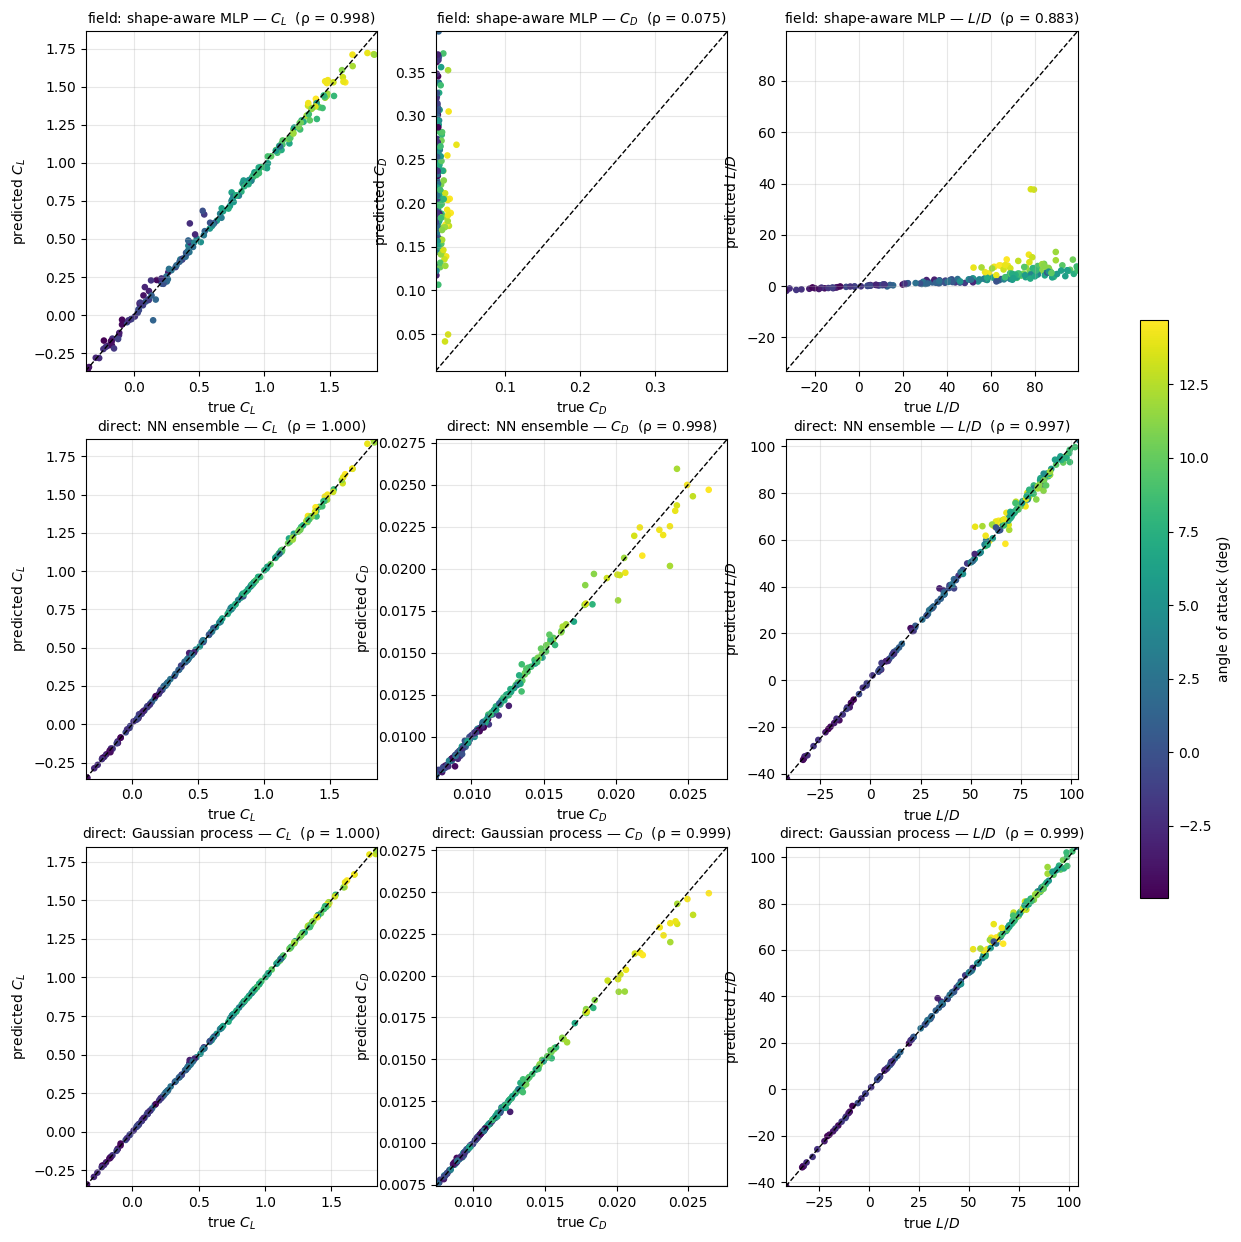

axes clipped to the 1st–99th percentile range


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 15))
for row, (m, lab) in enumerate(MODELS):
    for col, (c, C) in enumerate((('cl', '$C_L$'), ('cd', '$C_D$'), ('ld', '$L/D$'))):
        a = axes[row, col]
        x, y = test[f'true_{c}'], test[f'{m}_{c}']
        sc = a.scatter(x, y, c=test['aoa'], cmap='viridis', s=14)
        lo, hi = np.percentile(np.r_[x, y], [1, 99])
        a.plot([lo, hi], [lo, hi], 'k--', lw=1)
        a.set_xlim(lo, hi); a.set_ylim(lo, hi)
        a.set_xlabel(f'true {C}'); a.set_ylabel(f'predicted {C}')
        a.set_title(f'{lab} — {C}  (ρ = {spearmanr(x, y)[0]:.3f})', fontsize=10); a.grid(alpha=0.3)
fig.colorbar(sc, ax=axes, label='angle of attack (deg)', shrink=0.5)
plt.savefig(f'{OUT_DIR}/parity_direct.png', dpi=150, bbox_inches='tight'); plt.show()
print('axes clipped to the 1st–99th percentile range')

## 12. Behaviour across angle of attack
A physical sanity check for Phase 3: for one test airfoil at its own Reynolds number, the direct models are swept over the full angle-of-attack range. The curves should be smooth, with lift roughly linear in $\alpha$ and a drag minimum at moderate incidence. The single CFD point from the test set is marked.

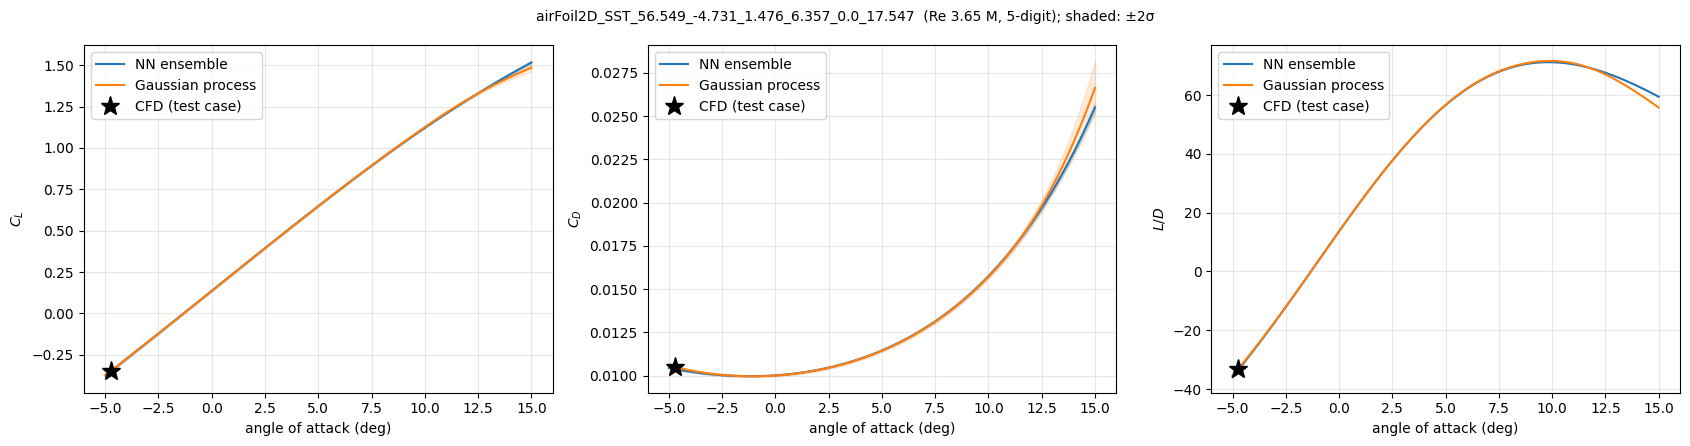

In [ ]:
k = int((rel('nn', 'ld') - rel('nn', 'ld').median()).abs().idxmin())
r = test.loc[k]
alphas = np.linspace(-5, 15, 81)
sweep = pd.DataFrame(dict(name=r['name'], aoa=alphas, re=r['re']))
Xs = features(sweep); Xs[:, len(G_NAMES)] = alphas
m_nn, s_nn = ens_predict(ensemble, Xs)
m_gp, s_gp = gp_predict(Xs)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for mu, sd, lab, col in ((m_nn, s_nn, 'NN ensemble', 'tab:blue'), (m_gp, s_gp, 'Gaussian process', 'tab:orange')):
    cl, cd = mu[:, 0], np.exp(mu[:, 1])
    ax[0].plot(alphas, cl, color=col, label=lab)
    ax[0].fill_between(alphas, cl - 2 * sd[:, 0], cl + 2 * sd[:, 0], color=col, alpha=0.15)
    ax[1].plot(alphas, cd, color=col, label=lab)
    ax[1].fill_between(alphas, np.exp(mu[:, 1] - 2 * sd[:, 1]), np.exp(mu[:, 1] + 2 * sd[:, 1]), color=col, alpha=0.15)
    ax[2].plot(alphas, cl / cd, color=col, label=lab)
for a, c, lab in zip(ax, ('cl', 'cd', 'ld'), ('$C_L$', '$C_D$', '$L/D$')):
    a.plot(r['aoa'], r[f'true_{c}'], 'k*', ms=14, label='CFD (test case)')
    a.set_xlabel('angle of attack (deg)'); a.set_ylabel(lab); a.grid(alpha=0.3); a.legend()
fig.suptitle(f"{r['name']}  (Re {r['re'] / 1e6:.2f} M, {r['family']}); shaded: ±2σ", fontsize=10)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/aoa_sweep.png', dpi=150, bbox_inches='tight'); plt.show()

## 13. Saved artefacts

In [ ]:
test.to_csv(f'{OUT_DIR}/test_direct_predictions.csv', index=False)
summary = dict(cfg=CFG, selected=dict(width=best_w, weight_decay=best_wd),
               grid=grid.to_dict(orient='records'),
               accuracy=acc.reset_index().to_dict(orient='records'),
               pairwise=pairs.reset_index().to_dict(orient='records'),
               calibration=calib.to_dict(orient='records'),
               gp_kernels=[str(g.kernel_) for g in gps], inputs=IN_NAMES)
with open(f'{OUT_DIR}/phase2b_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=float)
for p in sorted(glob.glob(f'{OUT_DIR}/*')):
    print(f'{os.path.getsize(p) / 1e6:8.2f} MB  {p}')

    0.14 MB  /content/drive/MyDrive/airfrans/phase2b/aoa_sweep.png
    0.23 MB  /content/drive/MyDrive/airfrans/phase2b/force_ensemble.pt
    0.47 MB  /content/drive/MyDrive/airfrans/phase2b/force_gp.joblib
    0.41 MB  /content/drive/MyDrive/airfrans/phase2b/parity_direct.png
    0.01 MB  /content/drive/MyDrive/airfrans/phase2b/phase2b_summary.json
    0.19 MB  /content/drive/MyDrive/airfrans/phase2b/test_direct_predictions.csv
    0.04 MB  /content/drive/MyDrive/airfrans/phase2b/train_forces.csv


In [ ]:
print('train/test overlap:', len(set(train_all['name']) & set(test['name'])))
mu_nn_va, _ = ens_predict(ensemble, X_va)
mu_gp_va, _ = gp_predict(X_va)
v = val[['name', 'aoa', 're', 'family', 'true_cd', 'true_cdp', 'true_cdv', 'true_cl']].copy()
v['gp_cd'], v['nn_cd'] = np.exp(mu_gp_va[:, 1]), np.exp(mu_nn_va[:, 1])
v['gp_err'] = (v['gp_cd'] / v['true_cd'] - 1).abs()
print('\nworst validation cases (GP drag):')
print(v.sort_values('gp_err', ascending=False).head(5).to_string(float_format=lambda x: f'{x:.4g}'))
t = test.assign(gp_err=rel('gp', 'cd')).sort_values('gp_err', ascending=False)
print('\nworst test cases (GP drag):')
print(t[['name', 'aoa', 're', 'true_cd', 'gp_cd', 'gp_err']].head(5).to_string(float_format=lambda x: f'{x:.4g}'))
print('\ntraining-set drag distribution:')
print(train_all['true_cd'].describe().to_string())

train/test overlap: 0

worst validation cases (GP drag):
                                                 name    aoa        re   family  true_cd  true_cdp  true_cdv  true_cl    gp_cd    nn_cd  gp_err
35  airFoil2D_SST_50.077_-4.416_2.834_4.029_1.0_5.156 -4.416 3.231e+06  5-digit  0.04595   0.04268  0.003269  -0.2829 0.009076 0.008738  0.8025
5       airFoil2D_SST_46.935_11.591_5.802_5.705_6.612  11.59 3.028e+06  4-digit  0.02452   0.01864  0.005884    1.754  0.02764  0.02632  0.1272
23      airFoil2D_SST_33.272_14.436_4.837_2.403_9.237  14.44 2.147e+06  4-digit   0.0305   0.02407  0.006431    1.775  0.02685  0.02877  0.1196
11  airFoil2D_SST_61.489_13.586_3.556_5.162_1.0_9.389  13.59 3.968e+06  5-digit  0.02149   0.01532  0.006169    1.655   0.0198  0.02144 0.07862
30  airFoil2D_SST_69.469_11.351_3.624_6.267_1.0_8.846  11.35 4.482e+06  5-digit  0.01641   0.01002  0.006394    1.522  0.01575   0.0165 0.04074

worst test cases (GP drag):
                                                  

## Summary
Direct surrogates map shape, angle of attack and Reynolds number straight to lift and drag. They are compared with the shape-aware field model on the same data and metrics: relative error, rank correlation, pairwise ordering at comparable conditions, and uncertainty calibration. The angle-of-attack sweep checks that the learned response is smooth and physically plausible across the design space, which a surrogate-driven optimizer depends on.

**Results.** Regressing forces directly removes the near-wall problem entirely.

| 200 test cases | field model | NN ensemble | Gaussian process |
|---|---|---|---|
| drag relative error, median | 1715 % | 0.8 % | 0.3 % |
| lift relative error, median | 2.6 % | 0.6 % | 0.3 % |
| drag rank correlation | 0.075 | 0.998 | 0.999 |
| L/D rank correlation | 0.883 | 0.997 | 0.999 |
| drag ordering, comparable and distinguishable pairs | 0.658 | 0.995 | 1.000 |
| fraction within ±2σ | – | 0.55 (CL) / 0.55 (log CD) | 0.91 / 0.91 |

The Gaussian process is the more accurate and the better calibrated of the two; the ensemble spread
measures disagreement between members and underestimates the actual error, so it should not be used
as an uncertainty estimate in Phase 4. The learned length scales identify incidence and thickness as
the dominant drivers of drag, followed by camber near 20 % and 80 % chord, with Reynolds number only
weakly influential over this range and nine of the thirteen descriptor entries effectively ignored,
as expected from their redundancy.

The angle-of-attack sweep behaves physically: lift is close to linear, the drag minimum sits near
−1°, and L/D peaks around 10°. The two models diverge only above about 13°, where training data is
sparse — which is also where the largest test errors occur (13 % worst case, at high incidence and
low Reynolds number).

The trade is explicit: field prediction and generality across arbitrary geometries are given up in
exchange for force accuracy within a parametric family. For parametric design optimization that is
the correct trade, and it is what makes Phase 3 possible.

**Next : Phase 3:** shape optimization with the direct surrogates: maximising $L/D$ and minimising $C_D$ subject to a lift constraint, comparing gradient-free search (Bayesian optimization) with gradient-based search using the network's own derivatives.